<a href="https://colab.research.google.com/github/khalid-bin-Nasir-0/ml_projects/blob/main/pro_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DIABETES

In [ ]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score



data collection and analysis

In [ ]:

# load dataset ---
data_dia = pd.read_csv("/content/drive/MyDrive/ML dataset/diabetes.csv")

In [ ]:
data_dia.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
data_dia.shape

(768, 9)

In [ ]:
data_dia.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
data_dia.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# check the no of diabetic and non diabetic vlaue in dataset
# label -- 0 for non diabetic and label -- 1 for diabetic
data_dia['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
 # NOW find out the all the value of feature for the outcom

data_dia.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [ ]:
# separating the data and labels

x = data_dia.drop(columns= 'Outcome',axis= 1)

y = data_dia['Outcome']

In [ ]:
# standardized tha data

scaler = StandardScaler()

scaler.fit(x)

std_data = scaler.transform(x)


In [ ]:
print(std_data)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [ ]:
x = std_data

In [ ]:
# Train test split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y , random_state = 2)


training model

In [ ]:
classifier = svm.SVC(kernel = 'linear')

In [ ]:
# training the svm classifier

classifier.fit(x_train, y_train)

SVC(kernel='linear')

Accuracy score :

In [ ]:
x_train_pred = classifier.predict(x_train)
training_data_accuracy = accuracy_score(x_train_pred , y_train)
print(training_data_accuracy)

0.7866449511400652


In [ ]:
# on test data accuracy

x_test_pred = classifier.predict(x_test)
test_data_accuracy = accuracy_score(x_test_pred , y_test)
print(test_data_accuracy)

0.7727272727272727


model evaluation

In [ ]:
#-------confusion matrix --------
from sklearn.metrics import confusion_matrix

In [ ]:
conf_metrix_pred = confusion_matrix(x_test_pred , y_test)
print(conf_metrix_pred)

[[91 26]
 [ 9 28]]


<Axes: >

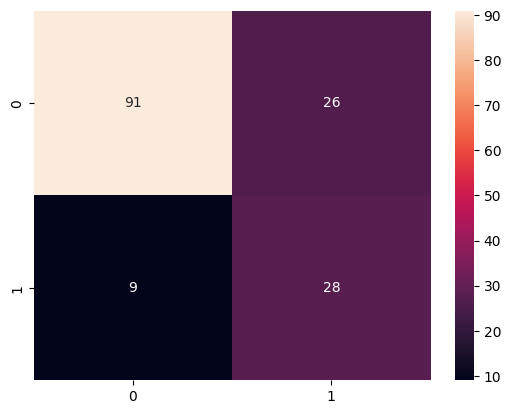

In [ ]:
import seaborn as sns
sns.heatmap(conf_metrix_pred,annot=True)

**precision**

In [ ]:
from sklearn.metrics import precision_score

precision_score_training = precision_score(x_train_pred , y_train)

precision_score_test = precision_score(x_test_pred , y_test)

print("precision score on training data --- ",precision_score_training)
print("precision score on test data data ----",precision_score_test)

# total predictive positive vs total actual positive is precision == total actual positive / total predictave +ve


precision score on training data ---  0.5887850467289719
precision score on test data data ---- 0.5185185185185185


**Recall**

In [ ]:
from sklearn.metrics import recall_score

recall_score_training = recall_score(x_train_pred , y_train)

recall_score_test = recall_score(x_test_pred , y_test)

print("recall score on training data --- ",recall_score_training)
print("recall score on test data data ----",recall_score_test)

# total +ve actual / out off how many predicted +ve  (tp + fn)

recall score on training data ---  0.7455621301775148
recall score on test data data ---- 0.7567567567567568


F1 **SCORE**

In [ ]:
from sklearn.metrics import f1_score

f1_score_training = f1_score(x_train_pred , y_train)

f1_score_test = f1_score(x_test_pred , y_test)

print("f1 score on training data --- ",f1_score_training)
print("f1 score on test data data ----",f1_score_test)



f1 score on training data ---  0.6579634464751958
f1 score on test data data ---- 0.6153846153846154


MAKING PREDICTIVE SYSTEM

In [ ]:
input_data = (0,141,0,0,0,42.4,0.205,29)


# changing the input data to numpy array

np_input_data = np.asarray(input_data)



# reshape the input data for predicting one instance -- mean = shaping it into matrix

reshpae_data =  np_input_data.reshape(1,-1)


# standardize the input data

std_data = scaler.transform(reshpae_data)

print(std_data)





[[-1.14185152  0.62924378 -3.57259724 -1.28821221 -0.69289057  1.32090213
  -0.8059981  -0.36084741]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
prediction = classifier.predict(std_data)

print(prediction)

[1]


warping model -- or saving the model

In [ ]:
import pickle

In [ ]:
filename = "dai_model.sav"
pickle.dump(classifier,open(filename,'wb')) # wb -- write in binary form

In [ ]:
# loaded model
dia_model = pickle.load(open('/content/dai_model.sav','rb')) # rb -- read the binary file

In [ ]:
input_data = (0,141,0,0,0,42.4,0.205,29)


# changing the input data to numpy array

np_input_data = np.asarray(input_data)



# reshape the input data for predicting one instance -- mean = shaping it into matrix

reshpae_data =  np_input_data.reshape(1,-1)


# standardize the input data

std_data = scaler.transform(reshpae_data)

print(std_data)





[[-1.14185152  0.62924378 -3.57259724 -1.28821221 -0.69289057  1.32090213
  -0.8059981  -0.36084741]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
prediction = dia_model.predict(std_data)

print(prediction)

[1]


# House price

In [ ]:
# importing the dependencies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.datasets import fetch_california_housing


In [ ]:
california_housing = fetch_california_housing()


In [ ]:
print(california_housing)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]]), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset:\n\nCalifornia Housing dataset\n-

In [ ]:
# load data into panda dataframe

cal_df = pd.DataFrame(california_housing.data)


# adding column form dataset to dataframe

cal_df = pd.DataFrame(california_housing.data , columns =  california_housing.feature_names)



In [ ]:
cal_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
# adding target column (mean price)

cal_df['price']=california_housing.target

In [ ]:
cal_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
cal_df.shape

(20640, 9)

In [ ]:
cal_df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
price,0


In [ ]:
cal_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


understanding the correlation bt feature and target

In [ ]:
corr = cal_df.corr()

<Axes: >

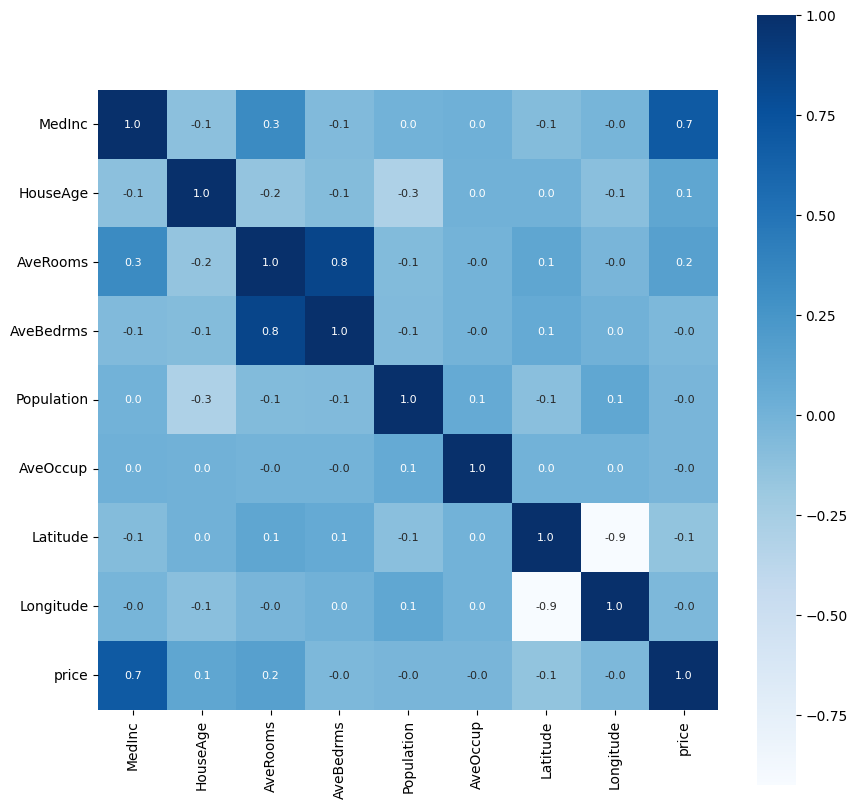

In [ ]:
# visualising the correlation by heatmap

plt.figure(figsize=(10,10))
sns.heatmap(corr,cbar = True , square= True, fmt='.1f' ,annot=True,annot_kws={'size':8},cmap='Blues')

spliting the data and target

In [ ]:
x = cal_df.drop(['price'], axis = 1)
y = cal_df['price']

In [ ]:
print(x)
print(y)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

In [ ]:
# spliting the data into training and test data

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2,random_state=2)

In [ ]:
x_train.shape

(16512, 8)

Model Training

XGBoost Regressor

In [ ]:
# loading the model
model= XGBRegressor()

In [ ]:
# traning the model
model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Evalution

In [ ]:
# prediction on training data

training_data_prediction = model.predict(x_train)

In [ ]:
print(training_data_prediction)

[0.5523039 3.0850039 0.5835302 ... 1.9204227 1.952873  0.6768683]


In [ ]:
training_data_prediction.shape

(16512,)

In [ ]:
# R squared error
score_1 =metrics.r2_score(y_train , training_data_prediction)

# mean absolute error
score_2 = metrics.mean_absolute_error(y_train, training_data_prediction)

print(score_1 ,'is the r squared error')
print(score_2,'mean square score' )

0.943650140819218 is the r squared error
0.1933648700612105 mean square score


In [ ]:
test_data_prediction = model.predict(x_test)

In [ ]:
# R squared error
score_1 =metrics.r2_score(y_test , test_data_prediction)

# mean absolute error
score_2 = metrics.mean_absolute_error(y_test, test_data_prediction)

print(score_1 ,'is the r squared error')
print(score_2,'mean square score' )

0.8338000331788725 is the r squared error
0.3108631800268186 mean square score


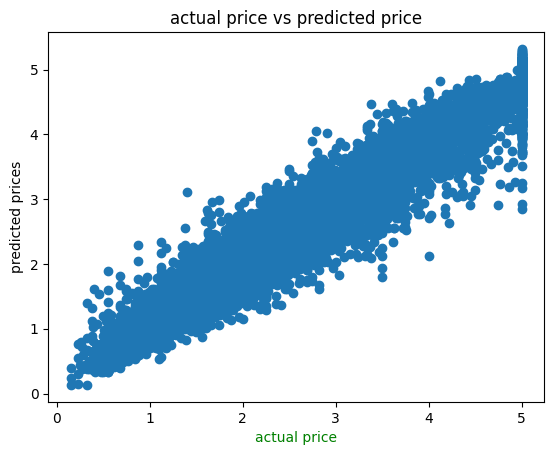

In [ ]:
# visualizing data predicted data and actual data

plt.scatter(y_train ,training_data_prediction)
plt.xlabel('actual price',color = 'g')
plt.ylabel('predicted prices')
plt.title('actual price vs predicted price')
plt.show()

# Fake News

About dataset

id : unique id for each news article

title : the title of news article

author : author of news article

text : the text of the article

could be incomplete

label : a label that make
weather the news article is real or fake .


In [ ]:

# importing the dependencies

import numpy as np
import pandas as pd
import re # it is use for searching the words,text in document
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# printing the stopwords

print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

data pre-processing

In [ ]:
# loading the dataset to a pandas DataFrame

news_ds = pd.read_csv('/content/drive/MyDrive/ML dataset/fake_news_train.csv')

In [ ]:
news_ds.shape

(20800, 5)

In [ ]:
news_ds.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [ ]:
# counting the missing value
news_ds.isnull().sum()

,0
id,0
title,558
author,1957
text,39
label,0


In [ ]:
# Replacing the null value with empty string

news_ds = news_ds.fillna('')

In [ ]:
# now we are merging the title and author for training the
# our model instead of the (text), beacuse of very good accuracy score and performance


# now merging

news_ds['content'] = news_ds['author']+''+news_ds['title']

In [ ]:
news_ds.head()

,id,title,author,text,label,content
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1,Darrell LucusHouse Dem Aide: We Didn’t Even Se...
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0,"Daniel J. FlynnFLYNN: Hillary Clinton, Big Wom..."
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1,Consortiumnews.comWhy the Truth Might Get You ...
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1,Jessica Purkiss15 Civilians Killed In Single U...
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1,Howard PortnoyIranian woman jailed for fiction...


In [ ]:
# seprating the data and label

x = news_ds.drop(columns= 'label',axis=1)
y = news_ds['label']

In [ ]:
print(x)
print(y)

          id                                              title  \
0          0  House Dem Aide: We Didn’t Even See Comey’s Let...   
1          1  FLYNN: Hillary Clinton, Big Woman on Campus - ...   
2          2                  Why the Truth Might Get You Fired   
3          3  15 Civilians Killed In Single US Airstrike Hav...   
4          4  Iranian woman jailed for fictional unpublished...   
...      ...                                                ...   
20795  20795  Rapper T.I.: Trump a ’Poster Child For White S...   
20796  20796  N.F.L. Playoffs: Schedule, Matchups and Odds -...   
20797  20797  Macy’s Is Said to Receive Takeover Approach by...   
20798  20798  NATO, Russia To Hold Parallel Exercises In Bal...   
20799  20799                          What Keeps the F-35 Alive   

                                          author  \
0                                  Darrell Lucus   
1                                Daniel J. Flynn   
2                             Consortiu

stemming :

In [ ]:
# stemming is the process of reducing a word to its root word -- mean remove all prefix and suffix

port_stem = PorterStemmer()


In [ ]:
# funtion for performing the stemming
def stemming(content):
  stemmed_cont = re.sub('[^a-zA-Z]',' ',content ) # here we subtitute all the other thing excpect a to z [^a-zA-Z] means(removing -- number and , and ? etc) from the input which i give to function , with the space .
  stemmed_cont = stemmed_cont.lower() # it make all word to lowercase
  stemmed_cont = stemmed_cont.split() # and then splits it into individual words.
  stemmed_cont = [port_stem.stem(word) for word in stemmed_cont if not word in stopwords.words('english')]
  stemmed_cont = ' '.join(stemmed_cont)
  return stemmed_cont

In [ ]:
# now apply the stemming funtion which i created , to our dataset which we use to train the model

news_ds['content'] = news_ds['content'].apply(stemming)

In [ ]:
print(news_ds['content'])

0        darrel lucushous dem aid even see comey letter...
1        daniel j flynnflynn hillari clinton big woman ...
2                consortiumnew comwhi truth might get fire
3        jessica purkiss civilian kill singl us airstri...
4        howard portnoyiranian woman jail fiction unpub...
                               ...                        
20795    jerom hudsonrapp trump poster child white supr...
20796    benjamin hoffmann f l playoff schedul matchup ...
20797    michael j de la merc rachel abramsmaci said re...
20798    alex ansarynato russia hold parallel exercis b...
20799                        david swansonwhat keep f aliv
Name: content, Length: 20800, dtype: object


In [ ]:
x = news_ds['content'].values #he .values attribute converts the pandas Series into NumPy arrays, which are a common format for machine learning models.
y = news_ds['label'].values

In [ ]:
print(x)

['darrel lucushous dem aid even see comey letter jason chaffetz tweet'
 'daniel j flynnflynn hillari clinton big woman campu breitbart'
 'consortiumnew comwhi truth might get fire' ...
 'michael j de la merc rachel abramsmaci said receiv takeov approach hudson bay new york time'
 'alex ansarynato russia hold parallel exercis balkan'
 'david swansonwhat keep f aliv']


In [ ]:
x.shape

(20800,)

now conveting the textual data to numerical data

In [ ]:
# this is beacuse computer don't understand the text so we convert into the numeric

vectorizer = TfidfVectorizer()
vectorizer.fit(x)
x = vectorizer.transform(x)

In [ ]:
print(x)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 198373 stored elements and shape (20800, 28419)>
  Coords	Values
  (0, 578)	0.2694167078545384
  (0, 4211)	0.36253203231506576
  (0, 5006)	0.24725958235728157
  (0, 5969)	0.35488202138141456
  (0, 6273)	0.2839932825877812
  (0, 8022)	0.2313366174248873
  (0, 12782)	0.24619727512767192
  (0, 14555)	0.2917725968420029
  (0, 15019)	0.4300622675963931
  (0, 22724)	0.25523360180691607
  (0, 26340)	0.2808837940159642
  (1, 2622)	0.3562953366945267
  (1, 3281)	0.18652439327549428
  (1, 3859)	0.45980466668763476
  (1, 4767)	0.23338756776626793
  (1, 5916)	0.31810058109638056
  (1, 8772)	0.5258635625386451
  (1, 11313)	0.24166773097712638
  (1, 27923)	0.36911845953845024
  (2, 5121)	0.5511414848555652
  (2, 5240)	0.40440534260277944
  (2, 8567)	0.3411947414020896
  (2, 9454)	0.30743020569262086
  (2, 16361)	0.43295215406038445
  (2, 26235)	0.3665032495181434
  :	:
  (20797, 1249)	0.3072223353708335
  (20797, 2257)	0.3357782642976524


In [ ]:
# spliting the training and test data

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=2)

now train the model

In [ ]:
# using logistic regression model

model= LogisticRegression()


In [ ]:
model.fit(x_train,y_train)

LogisticRegression()

accuracy score|

In [ ]:
# accuracy socre on training data

x_train_prediction = model.predict(x_train)
acc = accuracy_score(x_train_prediction ,y_train )

In [ ]:
print(acc)

0.971875


In [ ]:
# accuracy socre on testing data

x_test_prediction = model.predict(x_test)
acc = accuracy_score(x_test_prediction ,y_test )

In [ ]:
print(acc)

0.9550480769230769


now we are making predictive system

In [ ]:
x_new=x_test[15]

prediction = model.predict(x_new)

print(prediction)

[0]


In [ ]:
print(y_test[15])

0


In [ ]:
new = 'New Jersey Woman Charged After Her Son, 6, Fatally Shoots His Brother, 4 - The New York Times",Mireya Navarro,'

In [ ]:
stemmed_new_input = stemming(new)
vectorized_new_input = vectorizer.transform([stemmed_new_input])

print("Stemmed and vectorized new input:")
print(vectorized_new_input)

Stemmed and vectorized new input:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12 stored elements and shape (1, 28419)>
  Coords	Values
  (0, 3416)	0.3170089296809904
  (0, 4286)	0.2584497182042657
  (0, 8349)	0.31462431272609864
  (0, 12848)	0.3331994035056613
  (0, 16510)	0.4224325299932935
  (0, 17298)	0.4100874987698736
  (0, 17505)	0.18328460623853357
  (0, 23213)	0.263778983627511
  (0, 23848)	0.29317017142573776
  (0, 25776)	0.09311214985775255
  (0, 27923)	0.2634257959298604
  (0, 28256)	0.09430488349018838


In [ ]:
prediction = model.predict(vectorized_new_input)
print("The prediction for the new news article is:")
if prediction[0] == 0:
    print("Real News")
else:
    print("Fake News")

The prediction for the new news article is:
Real News


In [ ]:
x_new=

prediction = model.predict(x_new)

print(prediction)

# Loan Status

In [ ]:
# importing the dependencies

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score


Data collection and processing

In [ ]:
# loading the dataset

ls_df = pd.read_csv('/content/drive/MyDrive/ML dataset/loan_status.csv')

In [ ]:
ls_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
ls_df.shape

(614, 13)

In [ ]:
# statistical measure
ls_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
# misising value
ls_df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
# dropping the missing values

ls_df = ls_df.dropna()
ls_df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
# label encoding to our target where all the "no" replace with 0 , and "yes" with 1

ls_df.replace({"Loan_Status":{'N':0,'Y':1}},inplace = True)

/tmp/ipykernel_200/2948593500.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ls_df.replace({"Loan_Status":{'N':0,'Y':1}},inplace = True)


In [ ]:
ls_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [ ]:
# education column values

ls_df['Education'].value_counts()

,count
Education,
Graduate,383
Not Graduate,97


In [ ]:
# Married column values

ls_df['Married'].value_counts()

,count
Married,
Yes,311
No,169


In [ ]:
# Gender column values

ls_df['Gender'].value_counts()

,count
Gender,
Male,394
Female,86


In [ ]:
# Dependent column values

ls_df['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
3+,41


In [ ]:
# Dependents column have value of 3+ which is not relevent or not good value for model training
ls_df = ls_df.replace(to_replace='3+',value=4)

In [ ]:
# dependent values
ls_df['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
4,41


Data Visualization

<Axes: xlabel='Education', ylabel='count'>

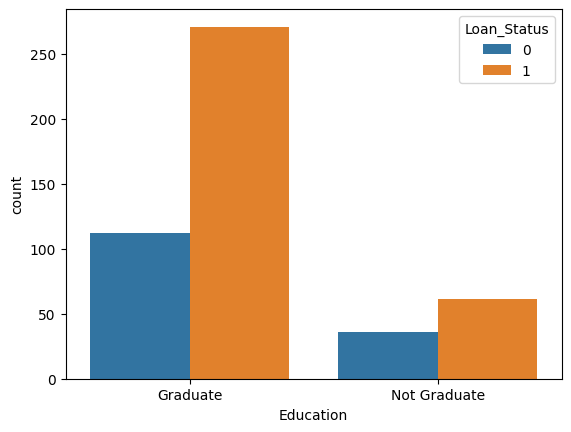

In [ ]:
# education & loan status
sns.countplot(x='Education',hue = 'Loan_Status',data=ls_df)

<Axes: xlabel='Married', ylabel='count'>

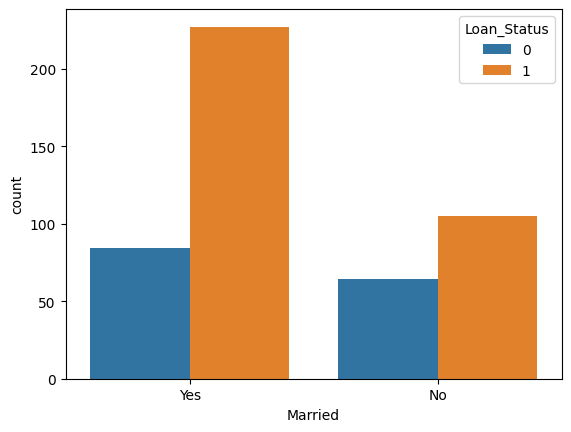

In [ ]:
# marital status & loan status 0 FOR no  , 1 for yes
sns.countplot(x='Married',hue='Loan_Status',data = ls_df)

In [ ]:
''' married - 0 = no , 1 = yes
 gender - 0 = female , 1 = male
 Self_Employed- No :0, Yes :1
 Property_Area : Rural: 0, Semiurban: 1 , Urban: 2
 Education : Graduate: 1, Not Graduate: 0 '''

' married - 0 = no , 1 = yes\n gender - 0 = female , 1 = male\n Self_Employed- No :0, Yes :1\n Property_Area : Rural: 0, Semiurban: 1 , Urban: 2\n Education : Graduate: 1, Not Graduate: 0 '

In [ ]:
# convert all the categorical column to numerical value
ls_df.replace({'Married':{'No':0,'Yes':1},'Gender':{'Male':1,'Female':0},'Self_Employed':{'No':0,'Yes':1},'Property_Area':{'Rural':0,'Semiurban':1,'Urban':2},'Education':{'Graduate':1,'Not Graduate':0}}, inplace = True)

/tmp/ipykernel_200/482819435.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ls_df.replace({'Married':{'No':0,'Yes':1},'Gender':{'Male':1,'Female':0},'Self_Employed':{'No':0,'Yes':1},'Property_Area':{'Rural':0,'Semiurban':1,'Urban':2},'Education':{'Graduate':1,'Not Graduate':0}}, inplace = True)


In [ ]:
ls_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1


In [ ]:
# seprating the data and label
x = ls_df.drop(columns=['Loan_Status','Loan_ID'], axis = 1 )
y = ls_df['Loan_Status']

In [ ]:
print(x)

     Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
1         1        1          1          1              0             4583   
2         1        1          0          1              1             3000   
3         1        1          0          0              0             2583   
4         1        0          0          1              0             6000   
5         1        1          2          1              1             5417   
..      ...      ...        ...        ...            ...              ...   
609       0        0          0          1              0             2900   
610       1        1          4          1              0             4106   
611       1        1          1          1              0             8072   
612       1        1          2          1              0             7583   
613       0        0          0          1              1             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_Hi

In [ ]:
# Train Test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=2)

In [ ]:
print(x.shape)

(480, 11)


In [ ]:
# training the model : svm

In [ ]:
classifier = svm.SVC(kernel = 'linear')

In [ ]:
classifier.fit(x_train,y_train)

SVC(kernel='linear')

In [ ]:
# accuracy score on training data
x_trian_pred = classifier.predict(x_train)
acc = accuracy_score(x_trian_pred,y_train)
print(acc)

0.7786458333333334


In [ ]:
# accuracy score on test data
x_test_pred = classifier.predict(x_test)
acc = accuracy_score(x_test_pred,y_test)
print(acc)

0.8125


predictive system

In [ ]:
new =

SyntaxError: invalid syntax (147544454.py, line 1)

# Gold Price Pred

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Data Collection and processing

In [ ]:
# loading the csv data to pandas dataframe
gold_data = pd.read_csv('/content/drive/MyDrive/ML dataset/gld_price_data.csv')


In [ ]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [ ]:
gold_data.shape

(2290, 6)

In [ ]:
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [ ]:
# getting basic info about data
gold_data.info()
gold_data.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [ ]:
# getting the statistical measures of the data
gold_data.describe()
# in this the 25% is mean that value of column are less than the 25%
# its percentile value

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [ ]:
# find the correlation between columns -- (it is good for regression problem)
gold_data = gold_data.drop(['Date'], axis = 1)
corr = gold_data.corr()

<Axes: >

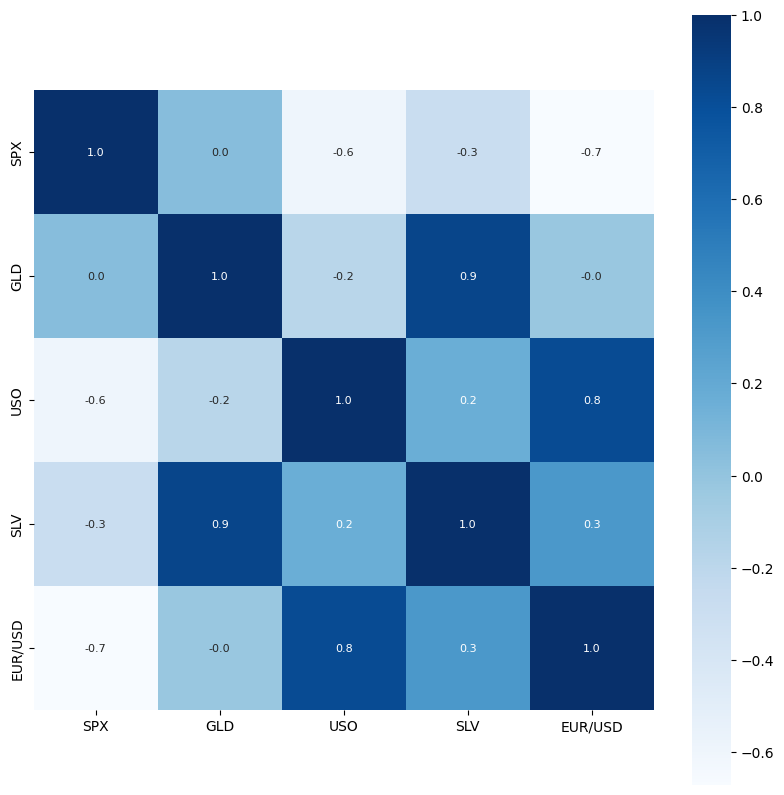

In [ ]:
# visualising the correlation by heatmap

plt.figure(figsize=(10,10))
sns.heatmap(corr,cbar = True , square= True, fmt='.1f' ,annot=True,annot_kws={'size':8},cmap='Blues')

In [ ]:
# correlation values of GLD
print(corr['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


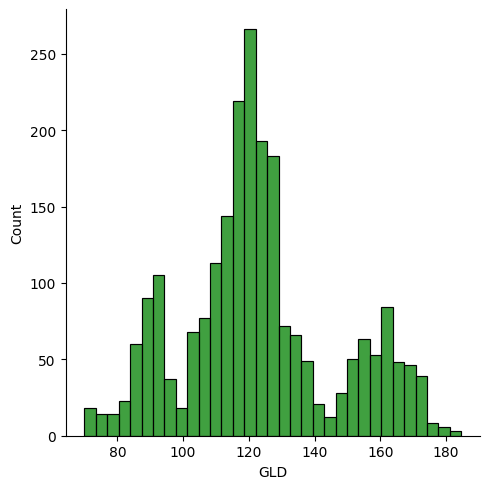

In [ ]:
#
sns.displot(gold_data['GLD'],color='green')

In [ ]:
# spliting the target and feature
x = gold_data.drop(['GLD'],axis= 1)
y = gold_data['GLD']

In [ ]:
# spliting into training data and test data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [ ]:
x_train.shape

(1832, 4)

Model training

In [ ]:
''' here we Random Forest algo which is ensembled model mean coinsist of two or more than two model
Random Forest ensembled model of multiple single decision tree '''
regressor = RandomForestRegressor(n_estimators=100)


In [ ]:
# training the model
regressor.fit(x_train,y_train)

RandomForestRegressor()

model evaluation

In [ ]:
x_train_pred = regressor.predict(x_train)

In [ ]:
# using R squared error
error_score = metrics.r2_score(x_train_pred,y_train)

In [ ]:
print(error_score)

0.9985586654819261


In [ ]:
x_test_pred = regressor.predict(x_test)
# using R squared error
error_score = metrics.r2_score(x_test_pred,y_test)
print(error_score)

0.988752707374493


# Big mart sales

In [ ]:
# importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics


In [ ]:
# data collection and analysis
bg_df = pd.read_csv('/content/drive/MyDrive/ML dataset/big mart data.csv')

In [ ]:
bg_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
bg_df.tail()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


In [ ]:
bg_df.shape

(8523, 12)

In [ ]:
bg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
bg_df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [ ]:
# handling the missing value of Item_Weight with mean
bg_df['Item_Weight'].fillna(bg_df['Item_Weight'].mean(),inplace = True)

/tmp/ipykernel_200/3612859433.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bg_df['Item_Weight'].fillna(bg_df['Item_Weight'].mean(),inplace = True)


In [ ]:
# handling the missing value of "Outlet_Size" with mode


In [ ]:
mode_of_outlet_size = bg_df.pivot_table(values = 'Outlet_Size', columns = 'Outlet_Type',aggfunc=(lambda x:x.mode()[0]))

# this line of code --- we compare outlet type to outlet size mean for particular outlat type which is most repted type or common

In [ ]:
print(mode_of_outlet_size)

Outlet_Type Grocery Store Supermarket Type1 Supermarket Type2  \
Outlet_Size         Small             Small            Medium   

Outlet_Type Supermarket Type3  
Outlet_Size            Medium  


In [ ]:
missing_value = bg_df['Outlet_Size'].isnull()
print(missing_value)

0       False
1       False
2       False
3        True
4       False
        ...  
8518    False
8519     True
8520    False
8521    False
8522    False
Name: Outlet_Size, Length: 8523, dtype: bool


In [ ]:
# Identify missing values in 'Outlet_Size'
missing_value = bg_df['Outlet_Size'].isnull()

# Get the 'Outlet_Type' for rows with missing 'Outlet_Size'
outlet_types_to_fix = bg_df.loc[missing_value, 'Outlet_Type']

# Map each 'Outlet_Type' to its corresponding mode from the 'mode_of_outlet_size' DataFrame
# .iloc[0] is used to extract the actual string value from the single-element Series that mode_of_outlet_size[x] returns
corrected_outlet_sizes = outlet_types_to_fix.apply(lambda x: mode_of_outlet_size[x].iloc[0])

# Assign the corrected string values back to the 'Outlet_Size' column
bg_df.loc[missing_value, 'Outlet_Size'] = corrected_outlet_sizes

In [ ]:
#bg_df = bg_df.dropna()
bg_df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [ ]:
bg_df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


Numerical Features

In [ ]:
sns.set()

<Figure size 800x800 with 0 Axes>

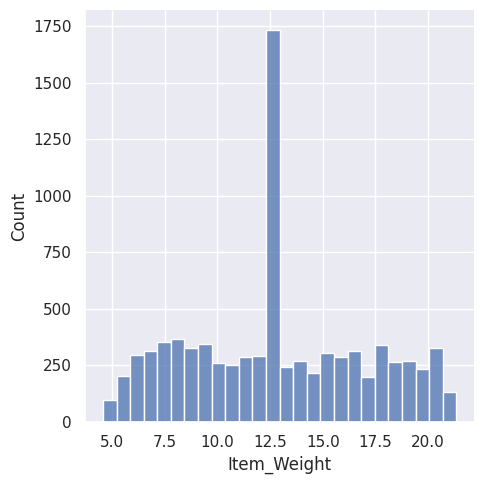

In [ ]:
# item_weight distribution
plt.figure(figsize=(8,8))
sns.displot(bg_df['Item_Weight'])
plt.show()

In [ ]:
# Count how many rows have Item_Weight = 10
xx = (bg_df['Item_Weight'] == 15.0).sum()
print(xx)


59


<Figure size 600x600 with 0 Axes>

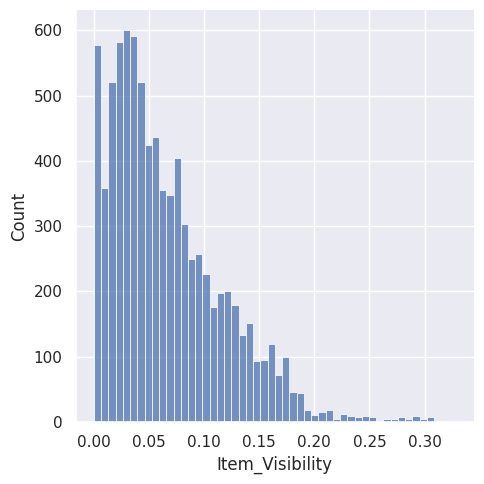

In [ ]:
# item_visibility distribution
plt.figure(figsize=(6 , 6))
sns.displot(bg_df['Item_Visibility'])
plt.show()

<Figure size 600x600 with 0 Axes>

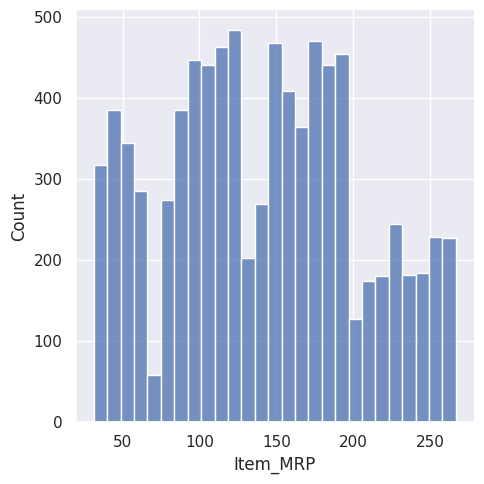

In [ ]:
# item_mrp distribution
plt.figure(figsize=(6 , 6))
sns.displot(bg_df['Item_MRP'])
plt.show()

<Figure size 600x600 with 0 Axes>

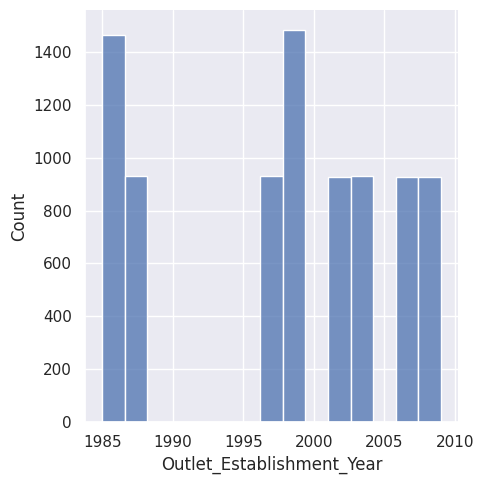

In [ ]:
# outlet_establisment
plt.figure(figsize=(6 , 6))
sns.displot(bg_df['Outlet_Establishment_Year'])
plt.show()

catogorical name

<Figure size 600x600 with 0 Axes>

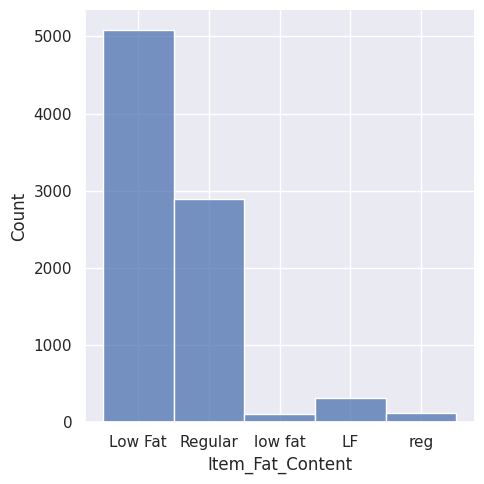

In [ ]:
# item_fat_content distribution
plt.figure(figsize=(6 , 6))
sns.displot(bg_df['Item_Fat_Content'])
plt.show()

<Figure size 3000x600 with 0 Axes>

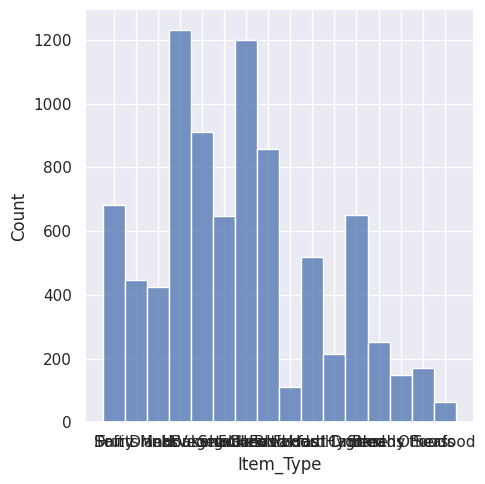

In [ ]:
# Item_Type distribution
plt.figure(figsize=(30 , 6))
sns.displot(bg_df['Item_Type'])
plt.show()

<Figure size 600x600 with 0 Axes>

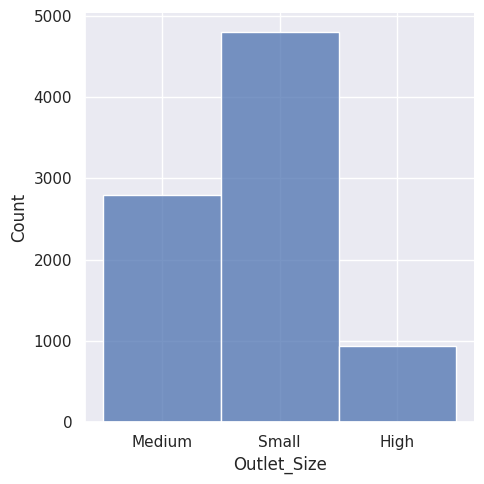

In [ ]:
# outlet_size  distribution
plt.figure(figsize=(6 , 6))
sns.displot(bg_df['Outlet_Size'])
plt.show()

Data pre - processing

In [ ]:
bg_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
bg_df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [ ]:
bg_df.replace({'Item_Fat_Content':{'low fat':'Low Fat','LF': 'Low Fat','reg':'Regular'}},inplace = True)

In [ ]:
bg_df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


Label encoding

In [ ]:
encoder = LabelEncoder()

In [ ]:

bg_df['Item_Identifier'] = encoder.fit_transform(bg_df['Item_Identifier'])
bg_df['Item_Fat_Content'] = encoder.fit_transform(bg_df['Item_Fat_Content'])
bg_df['Item_Type'] = encoder.fit_transform(bg_df['Item_Type'])
bg_df['Outlet_Identifier'] = encoder.fit_transform(bg_df['Outlet_Identifier'])
bg_df['Outlet_Size'] = encoder.fit_transform(bg_df['Outlet_Size'])
bg_df['Outlet_Location_Type'] = encoder.fit_transform(bg_df['Outlet_Location_Type'])
bg_df['Outlet_Type']=encoder.fit_transform(bg_df['Outlet_Type'])

In [ ]:
bg_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,156,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.20,1,0.000000,6,182.0950,0,1998,2,2,0,732.3800
4,1297,8.93,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052


In [ ]:
# splitting features and target
x = bg_df.drop(columns = 'Item_Outlet_Sales',axis = 1)
y = bg_df['Item_Outlet_Sales']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state = 3)

In [ ]:
print(x_train.shape,x_test.shape)

(6392, 11) (2131, 11)


Training model

In [ ]:
# xgboost regressor
regressor = XGBRegressor()


In [ ]:
regressor.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# prediction on training data
x_train_pred = regressor.predict(x_train)

In [ ]:
print(x_train_pred)

[1783.0149  2732.26     558.01227 ...  308.4572  1461.2546   380.4889 ]


In [ ]:
# R square value
r2_train = metrics.r2_score(y_train,x_train_pred)

In [ ]:
print(r2_train)

0.8846740382715818


In [ ]:
# prediction on x test
x_test_pred = regressor.predict(x_test)

In [ ]:
# R square value -- model evalution
r2_test = metrics.r2_score(y_test,x_test_pred)


In [ ]:
print(r2_test)

0.546356932309006


# Customer segmentaion

clustering -- unsupervised learning

In [ ]:
# importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [ ]:
customer_data = pd.read_csv('/content/drive/MyDrive/ML dataset/Mall_Customers.csv')

In [ ]:
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
customer_data.shape

(200, 5)

In [ ]:
# getting some info about the dataset
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
# checking for missing valuesd
customer_data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
# choosing the annual income column and spending score column
x = customer_data.iloc[:,[3,4]].values #  [:,[3,4]]  ":" this indicate all row select from the datasets [3,4]

choosing the correct no cluster

In [ ]:
# choosing the no cluster we use WCSS -- within cluster sum of squares
# which try to find value from centre of cluster to each data points .



so we use loop to find the  WCSS value for each cluster like 2 3 group -- and choose those which have lowest WCSS value

In [ ]:
# finding wcss value for different number of cluster
wcss = []
for i in range(1,11): # it means calculating no wcss value for no of cluster of our data between 1 to 10
  kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)# kmeans.inertia_ gives wcss values


In [ ]:
print(wcss)

[269981.28000000014, 183653.3289473683, 106348.37306211119, 73880.64496247198, 44448.45544793369, 40825.16946386947, 33642.57922077922, 26686.837785187785, 24766.471609793436, 23103.122085983905]


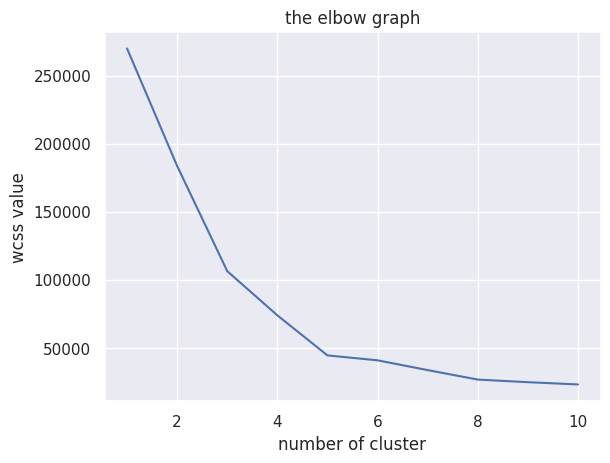

In [ ]:
# now plot the elbow graph
sns.set()
plt.plot(range(1,11),wcss)
plt.title('the elbow graph')
plt.xlabel('number of cluster')
plt.ylabel('wcss value')
plt.show()


after the elbow graph is created we chose the elbow point as our no of cluster,
the elbow point which have lowest wcss value

In [ ]:
# in this the optimum no cluster is 5


now training the k-means clustering model --  

In [ ]:
kmeans = KMeans(n_clusters=5,init='k-means++',random_state=0)

# return a label for each data -- means which cluster they belong
y = kmeans.fit_predict(x)
print(y)

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


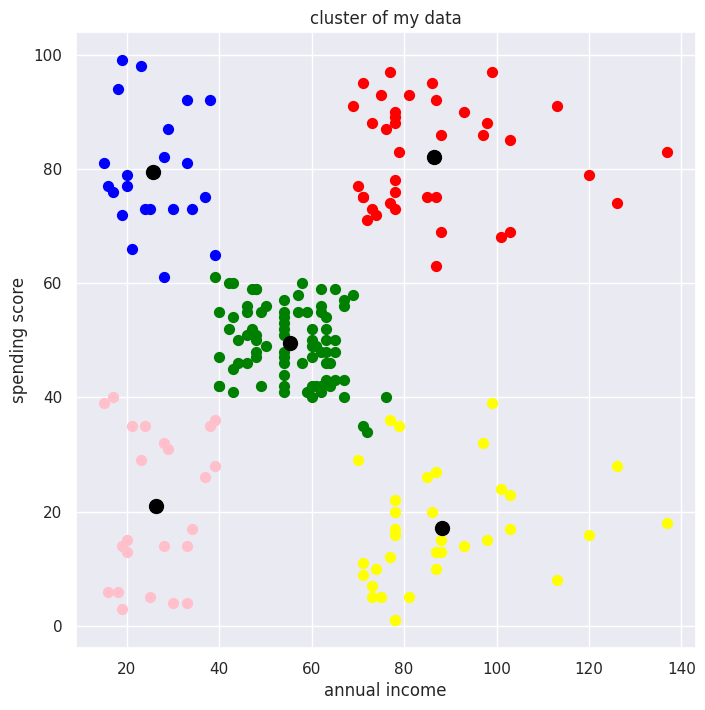

In [ ]:
# now doing visualizing the cluster with data for better understand
plt.figure(figsize=(8,8))
plt.scatter(x[y==0,0],x[y==0,1], s = 50,c='green',label='cluster 1')
plt.scatter(x[y==1,0],x[y==1,1], s = 50,c='red',label='cluster 2')
plt.scatter(x[y==2,0],x[y==2,1], s = 50,c='yellow',label='cluster 3')
plt.scatter(x[y==3,0],x[y==3,1], s = 50,c='pink',label='cluster 4')
plt.scatter(x[y==4,0],x[y==4,1], s = 50,c='blue',label='cluster 5')

# now we plot the centriod of cluster
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s= 100,c='black',label='centroids')
plt.title('cluster of my data')
plt.xlabel('annual income')
plt.ylabel('spending score')
plt.show()

In [ ]:
# for repeat and more understand open lecture and time stamp is 41 min